#

<div align=center>
<img src="https://uol.unifor.br/acesso/app/autenticacao/assets/img/logos/icon-unifor.svg" width=45 height=45>

<br><br>
<font size=5 color='black'><strong>MBA Ciência de dados:</strong> Estatística descritiva

<strong>Projeto:</strong> Titanic

<strong>Autoria:</strong> Heitor Teixeira

</div>

## <font color=darkblue> 1 - Imports e declaração de constantes

### <font color=steelblue> 1.1 - Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, gaussian_kde
import numpy as np
import requests


### <font color=steelblue> 1.2 - Constantes

Declarar constantes em uma unica celula facilita a manutenção de notebooks longos.<br>Alguns benefícios:
1. Melhorar a legibilidade do codigo
2. As constantes podem ser esquema de cores para padronizar sempre as mesmas cores para determinadas classes, paths de arquivos e datasets e etc.
3. posso modifica-las apenas aqui e servir para o codigo inteiro


In [2]:
# paths dos arquivos originais professor + Bank of England
PATH_TITANIC = 'datasets/titanic.csv'
PATH_BOE = 'datasets/extras/a-millennium-of-macroeconomic-data-for-the-uk.xlsx'

# paths dos arquivos feitos na feature engineering
PATH_BOE_CPI = 'datasets/boe_cpi.csv'  
PATH_WB_CPI  = 'datasets/wb_cpi.csv'   

# endpoint de APIs
API_WORLD_BANK = "https://api.worldbank.org/v2/country/GBR/indicator/FP.CPI.TOTL"

# constantes para  variaveis qualitativas e cabecalho
LABELS_CLASSE = {1: 'Primeira Classe', 2: 'Segunda Classe', 3: 'Terceira Classe'}

LABELS_GENERO = {'male': 'Masculino', 'female': 'Feminino'}

LABELS_SOBREVIVENTE = {0: 'Não Sobreviveu', 1: 'Sobreviveu'}

MAP_COLUMNS = {
    'Survived': 'Sobreviveu',
    'Pclass': 'Classe',
    'Name': 'Nome',
    'Sex': 'Genero',
    'Age': 'Idade',
    'Siblings/Spouses Aboard': 'Irmãos/Cônjuges a Bordo',
    'Parents/Children Aboard': 'Pais/Filhos a Bordo',
    'Fare': 'Tarifa',
}

## <font color=darkblue> 2 - Carregamento e Preparação do Dataset

### <font color=steelblue> 2.1 - Carregando o dataset original

**Observações**<br>
Esta análise considera `exclusivamente os passageiros do Titanic. Algumas decisões metodológicas foram adotadas para garantir maior clareza e consistência nos resultados:

1. Registros com `Fare = 0` foram excluídos, pois não é possível distinguir se pertencem a passageiros ou tripulantes, e sua presença poderia distorcer métricas e visualizações.
2. As variáveis qualitativas já são carregadas com mapeamento pelos valores definidos nas constantes, padronizando rótulos em tabelas e gráficos sem necessidade de configuração adicional.
3. Por essas razões, pequenas variações nos cálculos de média, mediana, desvio padrão e outras medidas em relação a outras análises do mesmo dataset são esperadas.

In [3]:
# carregando o dataset já renomeado com as constantes definidas na seçao 1.2
titanic_df = pd.read_csv(PATH_TITANIC, header=0, names=MAP_COLUMNS.values())

titanic_df = titanic_df[titanic_df['Tarifa']>0]

titanic_df['Classe'] = titanic_df['Classe'].map(LABELS_CLASSE)
titanic_df['Genero'] = titanic_df['Genero'].map(LABELS_GENERO)
titanic_df['Sobreviveu'] = titanic_df['Sobreviveu'].map(LABELS_SOBREVIVENTE)
titanic_df.tail(1)


,Sobreviveu,Classe,Nome,Genero,Idade,Irmãos/Cônjuges a Bordo,Pais/Filhos a Bordo,Tarifa
886,Não Sobreviveu,Terceira Classe,Mr. Patrick Dooley,Masculino,32.0,0,0,7.75


### <font color=steelblue> 2.2 - Feature Engineering

**Observações:***<br>
Em aula, o professor falou da importancia de considerar tanto valores absolutos quanto relativos. No caso do Titanic, como o acidente ocorreu em 1912, as tarifas originais estão completamente defasadas: £1 de 1912 não equivale a £1 hoje. <br><br>
Para preservar a noção de grandeza e permitir uma interpretação mais realista dos preços, adicionei uma coluna com a tarifa corrigida pela inflação. Os índices utilizados foram:

1. `Bank of England` - A Millennium of Macroeconomic Data for the UK (v3.1), aba A47, coluna H. Índice composto de preços do Reino Unido, normalizado para 100 em 2016. Cobre o período de 1912 a 2016.
2. `World Bank` - utilizado para estender a correção de 2016 até os anos mais recentes, complementando a série histórica do BoE.


#### <font color=slategray> 2.2.1 - Aquisição de dados externos

In [4]:
'''
essa celula é pra rodar só uma vez e depois comentar.
ela salva os datasets obtidos de APIs e dados externos para nao precisar puxar toda execucao


# extrai do Excel e salva em csv para evitar reler o arquivo de 27MB a cada execução
boe_df = pd.read_excel(
    PATH_BOE,
    sheet_name='A47. Wages and prices',
    header=6,       # as 6 primeiras linhas são metadados; a linha 6 é o cabeçalho real
    usecols=[0, 3], # col 0 = ano, col 3 = CPI preferred measure (GB/UK, base 2015=100)
)
boe_df.columns = ['Ano', 'Indice_CPI']
boe_df = boe_df.dropna(subset=['Ano', 'Indice_CPI'])
boe_df['Ano'] = boe_df['Ano'].astype(int)
boe_df.to_csv(PATH_BOE_CPI, index=False)

# obtém CPI de 2016 até 2024 via API e salva em csv pra nao chamar a API toda hora
# CPI é como se fosse a inflacao do UK -> Consumer Price Index
resp = requests.get(
    API_WORLD_BANK,
    params={"format": "json", "date": "2016:2024", "per_page": 20},
    timeout=10,
)
wb_df = pd.DataFrame(resp.json()[1])[["date", "value"]].dropna()
wb_df.columns = ['Ano', 'Indice_CPI']
wb_df['Ano'] = wb_df['Ano'].astype(int)
wb_df.to_csv(PATH_WB_CPI, index=False)

'''

'\nessa celula é pra rodar só uma vez e depois comentar.\nela salva os datasets obtidos de APIs e dados externos para nao precisar puxar toda execucao\n\n\n# extrai do Excel e salva em csv para evitar reler o arquivo de 27MB a cada execução\nboe_df = pd.read_excel(\n    PATH_BOE,\n    sheet_name=\'A47. Wages and prices\',\n    header=6,       # as 6 primeiras linhas são metadados; a linha 6 é o cabeçalho real\n    usecols=[0, 3], # col 0 = ano, col 3 = CPI preferred measure (GB/UK, base 2015=100)\n)\nboe_df.columns = [\'Ano\', \'Indice_CPI\']\nboe_df = boe_df.dropna(subset=[\'Ano\', \'Indice_CPI\'])\nboe_df[\'Ano\'] = boe_df[\'Ano\'].astype(int)\nboe_df.to_csv(PATH_BOE_CPI, index=False)\n\n# obtém CPI de 2016 até 2024 via API e salva em csv pra nao chamar a API toda hora\n# CPI é como se fosse a inflacao do UK -> Consumer Price Index\nresp = requests.get(\n    API_WORLD_BANK,\n    params={"format": "json", "date": "2016:2024", "per_page": 20},\n    timeout=10,\n)\nwb_df = pd.DataFrame(

#### <font color=slategray> 2.2.2 - Fator de inflação

In [5]:
# carrega os csvs salvos localmente, agora nao depende de API.
boe_df = pd.read_csv(PATH_BOE_CPI)
wb_df  = pd.read_csv(PATH_WB_CPI)

# fator BoE: corrige de 1912 até 2016
idx_1912  = boe_df.loc[boe_df['Ano'] == 1912, 'Indice_CPI'].values[0]
idx_2016  = boe_df.loc[boe_df['Ano'] == 2016, 'Indice_CPI'].values[0]
fator_boe = idx_2016 / idx_1912

# fator World Bank: estende a correção de 2016 até 2024
cpi_2016  = wb_df.loc[wb_df['Ano'] == 2016, 'Indice_CPI'].values[0]
cpi_2024  = wb_df.loc[wb_df['Ano'] == 2024, 'Indice_CPI'].values[0]
fator_wb  = cpi_2024 / cpi_2016

FATOR_INFLACAO = fator_boe * fator_wb


In [6]:
resumo_inflacao = pd.DataFrame(
    [
        {
            "Fonte": "Bank of England",
            "Período": "1912 → 2016",
            "Fator": f"{fator_boe:.2f}",
        },
        {
            "Fonte": "World Bank", 
            "Período": "2016 → 2024", 
            "Fator": f"{fator_wb:.4f}"
        },
        {
            "Fonte": "Total", 
            "Período": "1912 → 2024", 
            "Fator": f"{FATOR_INFLACAO:.2f}"
        },
    ]
)
print("Tabela 2.2.1 — Composição do fator de correção da inflação (1912 → 2024)")
display(resumo_inflacao.set_index("Fonte"))

Tabela 2.2.1 — Composição do fator de correção da inflação (1912 → 2024)


,Período,Fator
Fonte,,
Bank of England,1912 → 2016,81.46
World Bank,2016 → 2024,1.3153
Total,1912 → 2024,107.14


In [7]:
# aqui eu adiciono uma nova coluna para o dataset: tarifa atualizada com a inflacao
titanic_df["Tarifa 2024"] = (titanic_df["Tarifa"] * FATOR_INFLACAO).round(2)
titanic_df.tail(1)


,Sobreviveu,Classe,Nome,Genero,Idade,Irmãos/Cônjuges a Bordo,Pais/Filhos a Bordo,Tarifa,Tarifa 2024
886,Não Sobreviveu,Terceira Classe,Mr. Patrick Dooley,Masculino,32.0,0,0,7.75,830.3


### <font color=steelblue> 2.3 - Visão geral do dataset

In [8]:
visao_geral = pd.DataFrame(
    {
        "Tipo": titanic_df.dtypes,
        "Não nulos": titanic_df.notna().sum(),
        "Nulos": titanic_df.isna().sum(),
    }
)
visao_geral.index.name = "Coluna"

print(f"Tabela 2.3.1 - Visão geral do dataset ({len(titanic_df)} registros)")
display(visao_geral)

Tabela 2.3.1 - Visão geral do dataset (872 registros)


,Tipo,Não nulos,Nulos
Coluna,,,
Sobreviveu,str,872,0
Classe,str,872,0
Nome,str,872,0
Genero,str,872,0
Idade,float64,872,0
Irmãos/Cônjuges a Bordo,int64,872,0
Pais/Filhos a Bordo,int64,872,0
Tarifa,float64,872,0
Tarifa 2024,float64,872,0


## <font color=darkblue> 3 - Análise exploratória dos dados

### <font color=steelblue> 3.1 - Identificação das variáveis

Tabela com detalhes pedidos no briefing do projeto onde temos que identificar e classificas as features

In [9]:
# funcao para pegar os valores unicos das qualitativas separados por '/'
def valores_possiveis(col):
    return " / ".join(titanic_df[col].unique())


In [10]:
variaveis = pd.DataFrame(
    [
        {
            "Variável": "Sobreviveu",
            "Tipo": "Qualitativa",
            "Subtipo": "—",
            "Valores Possíveis": valores_possiveis("Sobreviveu"),
        },
        {
            "Variável": "Classe",
            "Tipo": "Qualitativa",
            "Subtipo": "—",
            "Valores Possíveis": valores_possiveis("Classe"),
        },
        {
            "Variável": "Nome",
            "Tipo": "Qualitativa",
            "Subtipo": "—",
            "Valores Possíveis": "Único por passageiro",
        },
        {
            "Variável": "Genero",
            "Tipo": "Qualitativa",
            "Subtipo": "—",
            "Valores Possíveis": valores_possiveis("Genero"),
        },
        {
            "Variável": "Idade",
            "Tipo": "Quantitativa",
            "Subtipo": "Contínua",
            "Valores Possíveis": "—",
        },
        {
            "Variável": "Irmãos/Cônjuges a Bordo",
            "Tipo": "Quantitativa",
            "Subtipo": "Discreta",
            "Valores Possíveis": "—",
        },
        {
            "Variável": "Pais/Filhos a Bordo",
            "Tipo": "Quantitativa",
            "Subtipo": "Discreta",
            "Valores Possíveis": "—",
        },
        {
            "Variável": "Tarifa",
            "Tipo": "Quantitativa",
            "Subtipo": "Contínua",
            "Valores Possíveis": "—",
        },
        {
            "Variável": "Tarifa 2024",
            "Tipo": "Quantitativa",
            "Subtipo": "Contínua",
            "Valores Possíveis": "—",
        },
    ]
)

# tirei o o maximo de caracteres para aparecer todos os valores
print("Tabela 3.1 — Identificação das variáveis do dataset Titanic")
with pd.option_context("display.max_colwidth", None):
    display(variaveis.set_index("Variável"))

Tabela 3.1 — Identificação das variáveis do dataset Titanic


,Tipo,Subtipo,Valores Possíveis
Variável,,,
Sobreviveu,Qualitativa,—,Não Sobreviveu / Sobreviveu
Classe,Qualitativa,—,Terceira Classe / Primeira Classe / Segunda Classe
Nome,Qualitativa,—,Único por passageiro
Genero,Qualitativa,—,Masculino / Feminino
Idade,Quantitativa,Contínua,—
Irmãos/Cônjuges a Bordo,Quantitativa,Discreta,—
Pais/Filhos a Bordo,Quantitativa,Discreta,—
Tarifa,Quantitativa,Contínua,—
Tarifa 2024,Quantitativa,Contínua,—


### <font color=steelblue> 3.2 - Distribuição da tarifa

#### <font color=slategray> 3.2.1 - Cálculo do bins

In [11]:
# aqui eu calculo o numero teorico de bins de acordo com o que foi ensinado em sala
# largura = (máximo - mínimo) / n_bins

n_bins = np.sqrt(len(titanic_df)).astype(int)

print(n_bins)

29


#### <font color=slategray> 3.2.2 - Histograma da tarifa (corrigido com inflação até 2024)

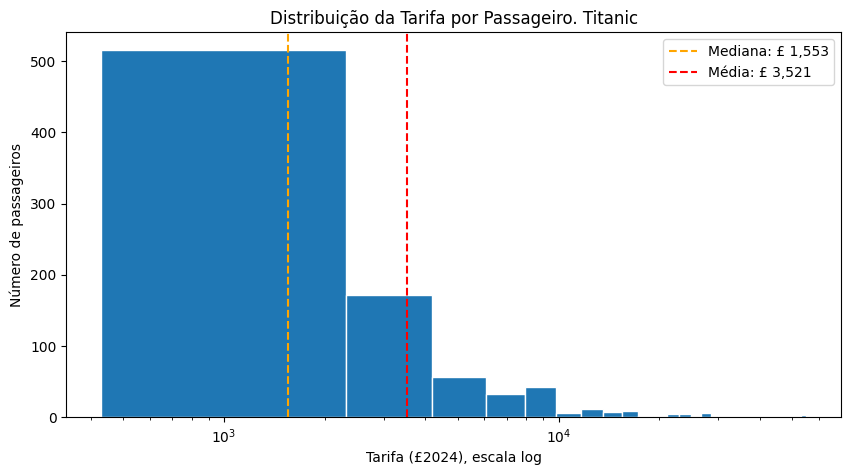

In [12]:
tarifas = titanic_df["Tarifa 2024"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(tarifas, bins=n_bins, edgecolor="white")

# como o histograma tem uma distribuição assimetrica para direita, utilizei a scala log como foi pedido no pdf
ax.set_xscale("log")
ax.set_xlabel("Tarifa (£2024), escala log")
ax.set_ylabel("Número de passageiros")
ax.set_title("Distribuição da Tarifa por Passageiro. Titanic")

# criação de linhas com as medidas de tendencia central
ax.axvline(
    tarifas.median(),
    color="orange",
    linestyle='--',
    label=f"Mediana: £ {tarifas.median():,.0f}",
    
)
ax.axvline(
    tarifas.mean(),
    color="red",
    linestyle='--',
    label=f"Média: £ {tarifas.mean():,.0f}",
)
ax.legend()
plt.show()

**Observações:**
- distribuição assimétrica à direita
- mediana: £ 1,553. média: £ 3.521. razão de ~2.3x
- concentração de tarifas elevadas em poucos passageiros
- distância grande entre média e mediana

### <font color=steelblue> 3.3 - Distribuição da idade

#### <font color=slategray> 3.3.1 - Histograma da idade

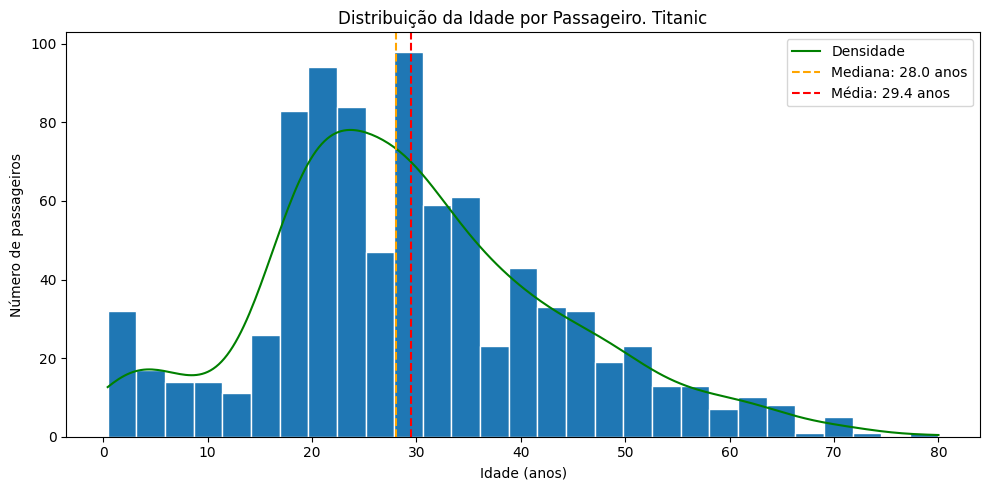

In [ ]:
idades = titanic_df["Idade"].dropna()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(idades, bins=n_bins, edgecolor="white")

# curva de densidade
# aqui eu já escalonei para voltar a unidade real
x_range = np.linspace(idades.min(), idades.max(), 300)
bin_width = (idades.max() - idades.min()) / n_bins
kde = gaussian_kde(idades)
kde_scaled = kde(x_range) * len(idades) * bin_width

ax.plot(x_range, kde_scaled, color="green", label="Densidade")
ax.set_xlabel("Idade (anos)")
ax.set_ylabel("Número de passageiros")
ax.set_title("Distribuição da Idade por Passageiro. Titanic")

# criação de linhas com as medidas de tendencia central
ax.axvline(
    idades.median(), 
    color="orange", 
    linestyle='--',
    label=f"Mediana: {idades.median():.1f} anos"
)
ax.axvline(
    idades.mean(), 
    color="red", 
    linestyle='--',
    label=f"Média: {idades.mean():.1f} anos"
)

ax.legend()
plt.show()

**Observações:**
- distribuição aproximadamente simétrica, levemente assimétrica à direita
- mediana e média próximas (~28 e ~29 anos), indicando menor influência de valores extremos que na tarifa
- concentração de passageiros entre 20 e 40 anos
- presença de crianças visível nas primeiras barras, mas em menor proporção